In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

x_train = x_train.reshape(-1,28,28,1)/255.0
x_test = x_test.reshape(-1,28,28,1)/255.0

In [3]:
def build_model():
    model = Sequential([
        Input(shape=(28,28,1)),
        Conv2D(32,(3,3),activation='relu'),
        MaxPooling2D(2,2),
        Conv2D(64,(3,3),activation='relu'),
        MaxPooling2D(2,2),
        Flatten(),
        Dense(128,activation='relu'),
        Dense(10,activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


In [4]:
model1 = build_model()
history1 = model1.fit(x_train, y_train, epochs=5, validation_data=(x_test,y_test))

Epoch 1/5
1875/1875 [==============================] - 49s 24ms/step - loss: 0.4362 - accuracy: 0.8417 - val_loss: 0.3321 - val_accuracy: 0.8804
Epoch 2/5
1875/1875 [==============================] - 37s 20ms/step - loss: 0.2943 - accuracy: 0.8927 - val_loss: 0.2976 - val_accuracy: 0.8905
Epoch 3/5
1875/1875 [==============================] - 41s 22ms/step - loss: 0.2491 - accuracy: 0.9083 - val_loss: 0.2828 - val_accuracy: 0.8960
Epoch 4/5
1875/1875 [==============================] - 47s 25ms/step - loss: 0.2154 - accuracy: 0.9204 - val_loss: 0.2730 - val_accuracy: 0.8982
Epoch 5/5
1875/1875 [==============================] - 42s 22ms/step - loss: 0.1920 - accuracy: 0.9279 - val_loss: 0.2543 - val_accuracy: 0.9118


In [5]:
datagen = ImageDataGenerator(rotation_range=10, zoom_range=0.1)
datagen.fit(x_train)
model2 = build_model()
history2 = model2.fit(datagen.flow(x_train, y_train, batch_size=32), epochs=5, validation_data=(x_test,y_test))

Epoch 1/5
1875/1875 [==============================] - 47s 24ms/step - loss: 0.5260 - accuracy: 0.8051 - val_loss: 0.3746 - val_accuracy: 0.8668
Epoch 2/5
1875/1875 [==============================] - 54s 29ms/step - loss: 0.3705 - accuracy: 0.8644 - val_loss: 0.3556 - val_accuracy: 0.8714
Epoch 3/5
1875/1875 [==============================] - 54s 29ms/step - loss: 0.3286 - accuracy: 0.8771 - val_loss: 0.3014 - val_accuracy: 0.8871
Epoch 4/5
1875/1875 [==============================] - 55s 29ms/step - loss: 0.2975 - accuracy: 0.8895 - val_loss: 0.2839 - val_accuracy: 0.8966
Epoch 5/5
1875/1875 [==============================] - 44s 23ms/step - loss: 0.2785 - accuracy: 0.8953 - val_loss: 0.2743 - val_accuracy: 0.9019


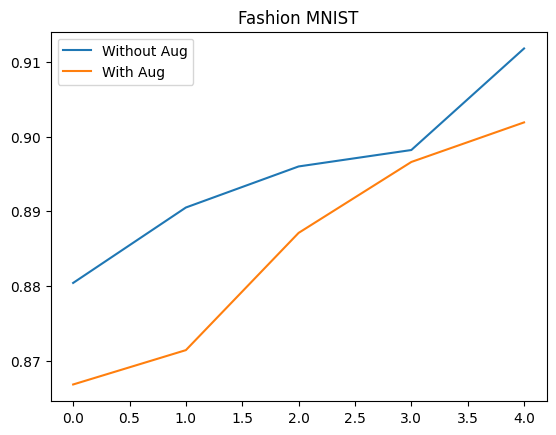

Conclusion: No Change ❌


In [6]:
plt.plot(history1.history['val_accuracy'], label='Without Aug')
plt.plot(history2.history['val_accuracy'], label='With Aug')
plt.legend(); plt.title("Fashion MNIST"); plt.show()

print("Conclusion:", "Improved ✅" if max(history2.history['val_accuracy']) > max(history1.history['val_accuracy']) else "No Change ❌")